# Is an autoencoder just a fancy PCA?

**A focused tutorial on the autoencoder bottleneck, using Fashion-MNIST.**

Author: Jyothi Kukati


This notebook is the companion code for the tutorial of the same name. It builds the
argument step by step:

1. A **linear** autoencoder trained with mean-squared error simply rediscovers **PCA**.
2. Adding **nonlinear** activations lets the same-sized bottleneck reconstruct the data
   *better* than PCA  most dramatically under hard compression.
3. The learned 2-D latent space separates the clothing classes more cleanly than the
   first two principal components.

Everything runs on a CPU in a couple of minutes and is reproducible from a fixed seed.

> **How to run:** execute the cells top to bottom. The data downloads automatically
> from the official Fashion-MNIST mirror on the first run.


## 0. Setup

Install the dependencies once (uncomment if needed), then import everything and fix the
random seeds so the results are reproducible.

In [1]:
# !pip install torch numpy scikit-learn matplotlib

import gzip, struct, os, urllib.request
import numpy as np
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs("figures", exist_ok=True)

# Colourblind-safe styling (Okabe-Ito palette + distinct marker shapes).
plt.rcParams.update({"figure.dpi": 120, "font.size": 12, "axes.titlesize": 13,
                     "axes.spines.top": False, "axes.spines.right": False})
OKABE_ITO = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
             '#0072B2', '#D55E00', '#CC79A7', '#000000']
MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>']
print("Using device:", DEVICE)

Using device: cpu


## 1. Load Fashion-MNIST

Fashion-MNIST contains 70,000 greyscale 28×28 images of clothing in 10 classes. We
download the original IDX files from the dataset authors' GitHub mirror (no extra
libraries needed) and work with a fixed random subset for speed and reproducibility.

In [2]:
DATA_DIR = "data/fashion"
BASE_URL = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion"
FILES = ["train-images-idx3-ubyte.gz", "train-labels-idx1-ubyte.gz",
         "t10k-images-idx3-ubyte.gz",  "t10k-labels-idx1-ubyte.gz"]

def download_fashion_mnist():
    os.makedirs(DATA_DIR, exist_ok=True)
    for f in FILES:
        dest = os.path.join(DATA_DIR, f)
        if not os.path.exists(dest):
            print("downloading", f)
            urllib.request.urlretrieve(f"{BASE_URL}/{f}", dest)

def read_idx(path):
    with gzip.open(path, "rb") as fh:
        magic, = struct.unpack(">I", fh.read(4))
        if magic == 2051:                       # images
            n, r, c = struct.unpack(">III", fh.read(12))
            return np.frombuffer(fh.read(), np.uint8).reshape(n, r * c)
        n, = struct.unpack(">I", fh.read(4))    # labels
        return np.frombuffer(fh.read(), np.uint8)

download_fashion_mnist()
X_train = read_idx(f"{DATA_DIR}/train-images-idx3-ubyte.gz").astype(np.float32) / 255.0
y_train = read_idx(f"{DATA_DIR}/train-labels-idx1-ubyte.gz")
X_test  = read_idx(f"{DATA_DIR}/t10k-images-idx3-ubyte.gz").astype(np.float32) / 255.0
y_test  = read_idx(f"{DATA_DIR}/t10k-labels-idx1-ubyte.gz")

# Fixed subsets keep the notebook fast and deterministic.
rng = np.random.default_rng(SEED)
tr = rng.choice(len(X_train), 15000, replace=False)
te = rng.choice(len(X_test),   5000, replace=False)
X_train, y_train = X_train[tr], y_train[tr]
X_test,  y_test  = X_test[te],  y_test[te]

CLASSES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
print("train:", X_train.shape, " test:", X_test.shape)

downloading train-images-idx3-ubyte.gz
downloading train-labels-idx1-ubyte.gz
downloading t10k-images-idx3-ubyte.gz
downloading t10k-labels-idx1-ubyte.gz
train: (15000, 784)  test: (5000, 784)


Each image is flattened to a 784-dimensional vector with pixel values scaled to
`[0, 1]`. Let's look at one example per class.

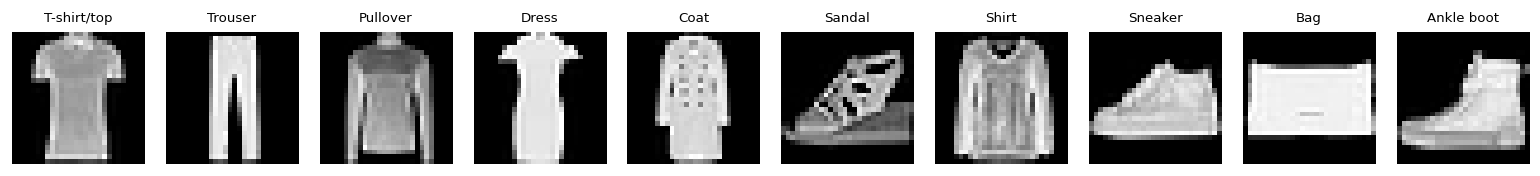

In [3]:
fig, axes = plt.subplots(1, 10, figsize=(13, 1.8))
for c in range(10):
    j = np.where(y_test == c)[0][0]
    axes[c].imshow(X_test[j].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    axes[c].set_title(CLASSES[c], fontsize=8)
    axes[c].axis("off")
plt.tight_layout(); plt.show()

## 2. Baseline: PCA

PCA is the standard *linear* dimensionality reducer: it projects the data onto the `d`
directions of greatest variance. To compare it fairly with an autoencoder we measure how
well it **reconstructs** held-out images after squeezing them through `d` components.

In [4]:
def pca_reconstruction_mse(d):
    pca = PCA(n_components=d, random_state=SEED).fit(X_train)
    recon = pca.inverse_transform(pca.transform(X_test))
    return float(((recon - X_test) ** 2).mean()), pca

LATENTS = [2, 4, 8, 16, 32]
pca_err, pca_models = {}, {}
for d in LATENTS:
    pca_err[d], pca_models[d] = pca_reconstruction_mse(d)
print({d: round(e, 5) for d, e in pca_err.items()})

{2: 0.0459, 4: 0.03656, 8: 0.0267, 16: 0.02053, 32: 0.01522}


## 3. The autoencoder

An autoencoder is a neural network trained to copy its input to its output through a
narrow **bottleneck**. The *encoder* compresses `784 → d`; the *decoder* expands
`d → 784`. Because the bottleneck is small, the network cannot just pass the image
through it must learn an efficient code.

The crucial design choice for this tutorial is the **activation function**. With
`nonlinear=False` every layer is linear, so the whole network is a linear map. With
`nonlinear=True` we insert ReLU nonlinearities.

In [5]:
class Autoencoder(nn.Module):
    def __init__(self, latent, nonlinear=True):
        super().__init__()
        act = nn.ReLU if nonlinear else nn.Identity
        self.encoder = nn.Sequential(
            nn.Linear(784, 256), act(),
            nn.Linear(256, 64),  act(),
            nn.Linear(64, latent))
        self.decoder = nn.Sequential(
            nn.Linear(latent, 64), act(),
            nn.Linear(64, 256),    act(),
            nn.Linear(256, 784))
        # A sigmoid output suits the [0,1] pixels; the *linear* model stays fully
        # linear so it can reproduce the PCA solution exactly.
        self.out = nn.Sigmoid() if nonlinear else nn.Identity()

    def forward(self, x):
        z = self.encoder(x)
        return self.out(self.decoder(z)), z

def train_autoencoder(latent, nonlinear=True, epochs=45, batch=256, lr=1e-3):
    torch.manual_seed(SEED)
    model = Autoencoder(latent, nonlinear).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    X = torch.tensor(X_train, device=DEVICE)
    for _ in range(epochs):
        perm = torch.randperm(len(X))
        for i in range(0, len(X), batch):
            b = X[perm[i:i + batch]]
            opt.zero_grad()
            out, _ = model(b)
            loss_fn(out, b).backward()
            opt.step()
    return model

def test_mse(model):
    model.eval()
    with torch.no_grad():
        out, _ = model(torch.tensor(X_test, device=DEVICE))
    return float(((out.cpu().numpy() - X_test) ** 2).mean())

def encode(model, X):
    model.eval()
    with torch.no_grad():
        _, z = model(torch.tensor(X, device=DEVICE))
    return z.cpu().numpy()

def reconstruct(model, X):
    model.eval()
    with torch.no_grad():
        out, _ = model(torch.tensor(X, device=DEVICE))
    return out.cpu().numpy()

## 4. A linear autoencoder is just PCA

Baldi & Hornik (1989) and Bourlard & Kamp (1988) proved that a linear autoencoder
trained with squared-error loss spans the same subspace as PCA, and reaches the same
reconstruction error. Let's confirm it: train a fully linear autoencoder with a 32-unit
bottleneck and compare its test error with PCA using 32 components.

In [6]:
linear_ae = train_autoencoder(32, nonlinear=False, epochs=60)
linear_ae_err = test_mse(linear_ae)
print(f"Linear autoencoder (d=32): {linear_ae_err:.5f}")
print(f"PCA              (d=32): {pca_err[32]:.5f}")
print("The two match to within training noise — the linear AE rediscovers PCA.")

Linear autoencoder (d=32): 0.01530
PCA              (d=32): 0.01522
The two match to within training noise — the linear AE rediscovers PCA.


## 5. Turn the knob: nonlinear autoencoder vs PCA

Now we train a **nonlinear** autoencoder at each bottleneck size and compare it with PCA
on identical reconstruction error. This is the core experiment.

In [7]:
ae_err, ae_models = {}, {}
for d in LATENTS:
    ae_models[d] = train_autoencoder(d, nonlinear=True)
    ae_err[d] = test_mse(ae_models[d])
    print(f"nonlinear AE d={d:>2}: {ae_err[d]:.5f}   (PCA: {pca_err[d]:.5f})")

nonlinear AE d= 2: 0.02814   (PCA: 0.04590)
nonlinear AE d= 4: 0.01997   (PCA: 0.03656)
nonlinear AE d= 8: 0.01586   (PCA: 0.02670)
nonlinear AE d=16: 0.01473   (PCA: 0.02053)
nonlinear AE d=32: 0.01426   (PCA: 0.01522)


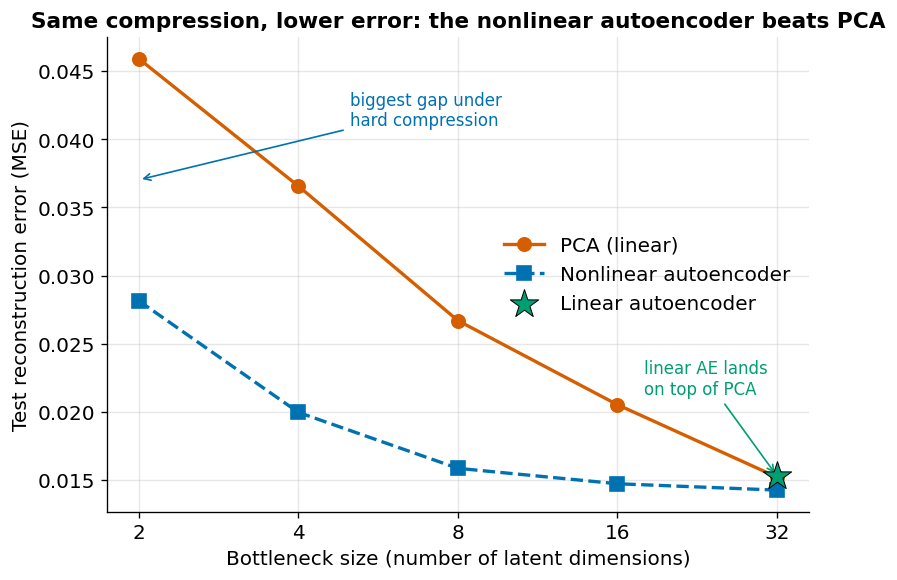

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(LATENTS, [pca_err[d] for d in LATENTS], color='#D55E00', ls='-',
        marker='o', ms=8, lw=2, label="PCA (linear)")
ax.plot(LATENTS, [ae_err[d] for d in LATENTS], color='#0072B2', ls='--',
        marker='s', ms=8, lw=2, label="Nonlinear autoencoder")
ax.scatter([32], [linear_ae_err], color='#009E73', marker='*', s=320, zorder=5,
           edgecolor='black', lw=0.6, label="Linear autoencoder")
ax.annotate("linear AE lands\non top of PCA", xy=(32, linear_ae_err),
            xytext=(18, linear_ae_err + 0.006), fontsize=10, color='#009E73',
            arrowprops=dict(arrowstyle="->", color='#009E73'))
ax.annotate("biggest gap under\nhard compression",
            xy=(2, (pca_err[2] + ae_err[2]) / 2), xytext=(5, 0.041),
            fontsize=10, color='#0072B2', arrowprops=dict(arrowstyle="->", color='#0072B2'))
ax.set_xscale("log", base=2); ax.set_xticks(LATENTS); ax.set_xticklabels(LATENTS)
ax.set_xlabel("Bottleneck size (number of latent dimensions)")
ax.set_ylabel("Test reconstruction error (MSE)")
ax.set_title("Same compression, lower error: the nonlinear autoencoder beats PCA",
             weight="bold")
ax.legend(frameon=False); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("figures/fig2_error_curve.png", bbox_inches="tight"); plt.show()

## 6. What the compression looks like

Numbers are convincing, but pictures make it concrete. Here we rebuild one item per class
from a tiny **8-number** code. PCA blurs the detail; the autoencoder keeps shapes such as
the gap between trouser legs and the straps of the sandal.

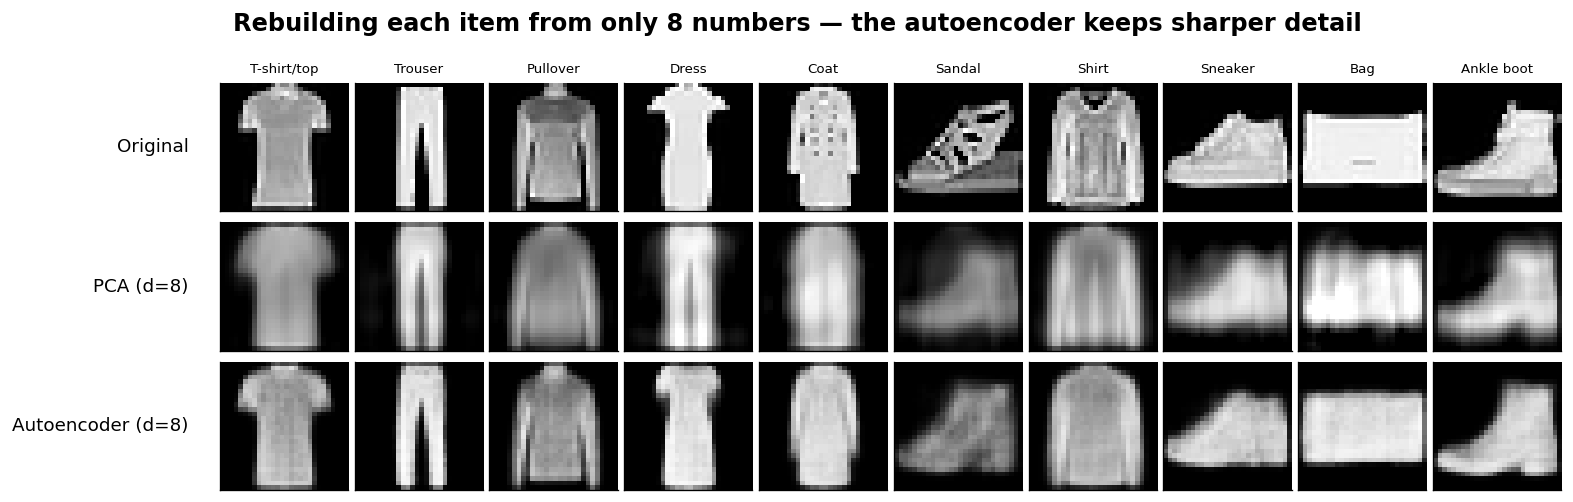

In [9]:
d = 8
pca8 = pca_models[d].inverse_transform(pca_models[d].transform(X_test))
ae8 = reconstruct(ae_models[d], X_test)
idx = [np.where(y_test == c)[0][0] for c in range(10)]

fig, axes = plt.subplots(3, 10, figsize=(13, 4.4))
rows = [("Original", X_test), (f"PCA (d={d})", pca8), (f"Autoencoder (d={d})", ae8)]
for ri, (name, arr) in enumerate(rows):
    for ci, j in enumerate(idx):
        axes[ri, ci].imshow(arr[j].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        axes[ri, ci].set_xticks([]); axes[ri, ci].set_yticks([])
        if ri == 0:
            axes[ri, ci].set_title(CLASSES[ci], fontsize=8)
fig.subplots_adjust(left=0.13, right=0.99, top=0.80, bottom=0.02, wspace=0.05, hspace=0.05)
for ri, (name, _) in enumerate(rows):
    pos = axes[ri, 0].get_position()
    fig.text(0.11, (pos.y0 + pos.y1) / 2, name, ha="right", va="center", fontsize=11)
fig.suptitle("Rebuilding each item from only 8 numbers — the autoencoder keeps sharper detail",
             weight="bold", y=0.93)
plt.savefig("figures/fig3_reconstructions.png"); plt.show()

## 7. The latent space

Finally we squeeze all the way down to **2 dimensions** so we can plot the code directly.
The autoencoder pulls footwear, trousers and tops into separate arms, while PCA's first
two components leave the classes overlapping. Every class uses both a distinct colour and
a distinct marker, so the plot is readable without relying on colour.

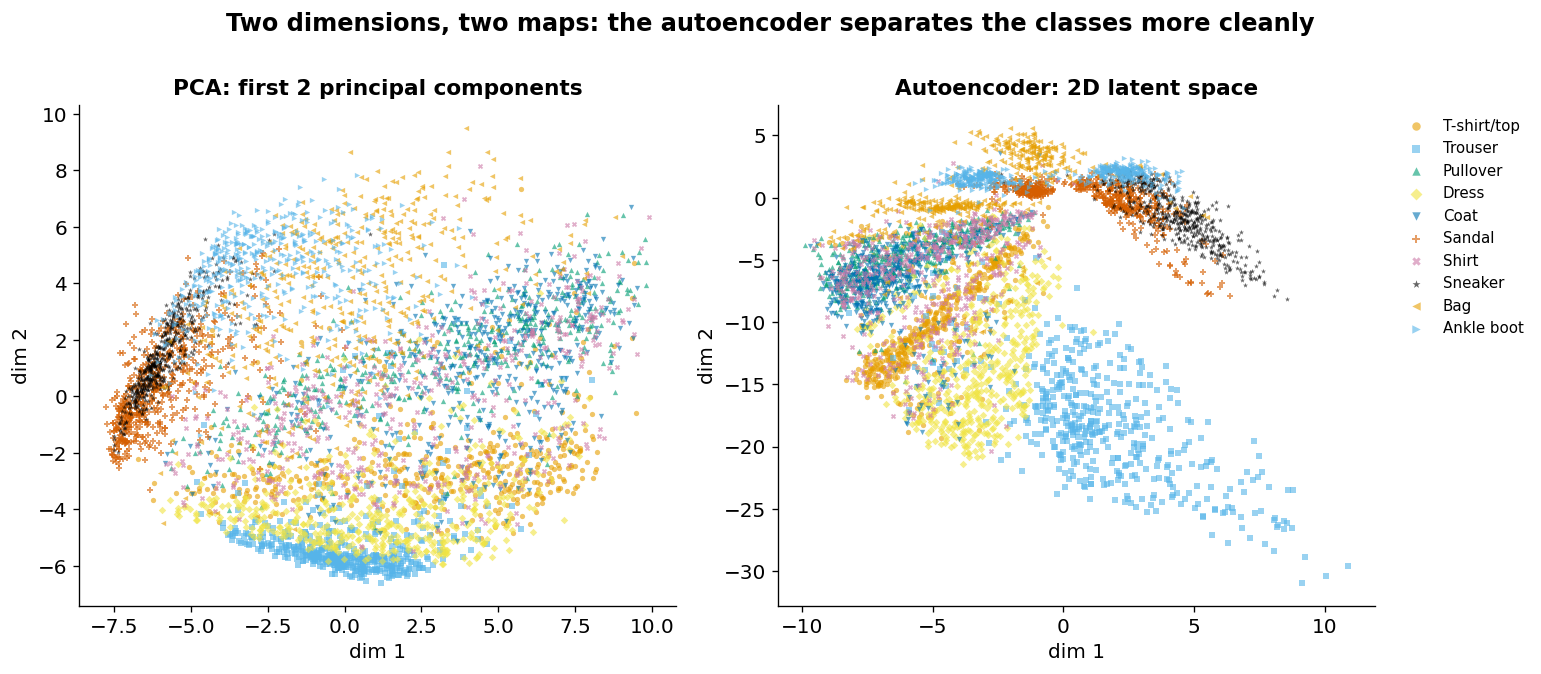

In [10]:
ae2 = train_autoencoder(2, nonlinear=True)
z_ae  = encode(ae2, X_test)
z_pca = pca_models[2].transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
for ax, Z, title in [(axes[0], z_pca, "PCA: first 2 principal components"),
                     (axes[1], z_ae,  "Autoencoder: 2D latent space")]:
    for c in range(10):
        sel = y_test == c
        ax.scatter(Z[sel, 0], Z[sel, 1], s=10, alpha=0.6, color=OKABE_ITO[c % 8],
                   marker=MARKERS[c], linewidths=0, label=CLASSES[c])
    ax.set_title(title, weight="bold"); ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False,
               fontsize=9, markerscale=1.6)
fig.suptitle("Two dimensions, two maps: the autoencoder separates the classes more cleanly",
             weight="bold", y=1.0)
plt.tight_layout(); plt.savefig("figures/fig4_latent_space.png", bbox_inches="tight"); plt.show()

## Appendix: architecture diagram

The schematic used in the written tutorial, reproduced here for completeness.

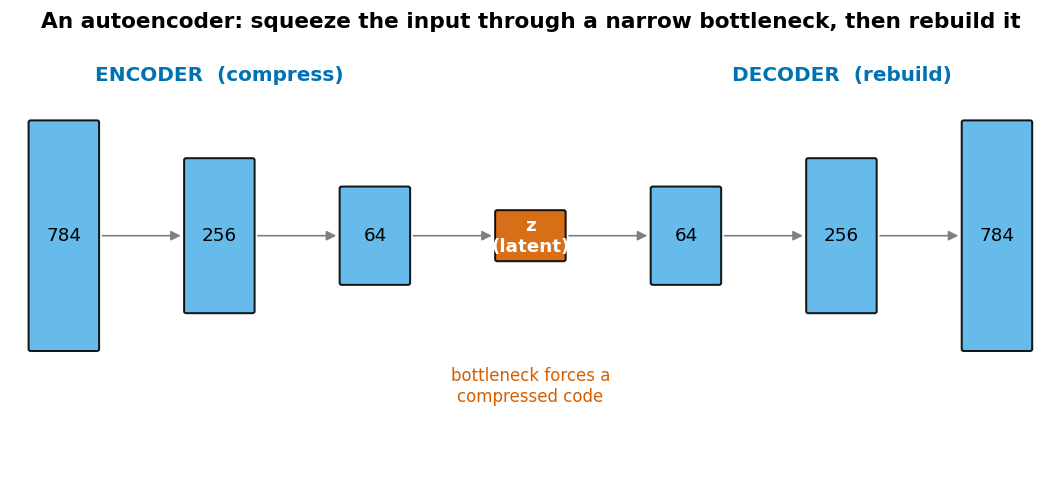

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.2)); ax.axis("off")
sizes = [("784", 2.4), ("256", 1.6), ("64", 1.0), ("z", 0.5),
         ("64", 1.0), ("256", 1.6), ("784", 2.4)]
xs = np.linspace(0.5, 9.5, len(sizes))
for i, ((lab, h), x) in enumerate(zip(sizes, xs)):
    col = '#D55E00' if lab == "z" else '#56B4E9'
    ax.add_patch(FancyBboxPatch((x - 0.32, 2.5 - h / 2), 0.64, h,
                 boxstyle="round,pad=0.02", fc=col, ec="black", lw=1.2, alpha=0.9))
    ax.text(x, 2.5, lab if lab != "z" else "z\n(latent)", ha="center", va="center",
            fontsize=11, weight="bold" if lab == "z" else "normal",
            color="white" if lab == "z" else "black")
    if i < len(sizes) - 1:
        ax.add_patch(FancyArrowPatch((x + 0.34, 2.5), (xs[i + 1] - 0.34, 2.5),
                     arrowstyle="-|>", mutation_scale=12, lw=1, color="gray"))
ax.text(xs[1], 4.15, "ENCODER  (compress)", ha="center", fontsize=12, weight="bold", color='#0072B2')
ax.text(xs[5], 4.15, "DECODER  (rebuild)",  ha="center", fontsize=12, weight="bold", color='#0072B2')
ax.text(xs[3], 0.75, "bottleneck forces a\ncompressed code", ha="center", fontsize=10, color='#D55E00')
ax.set_xlim(0, 10); ax.set_ylim(0, 4.6)
ax.set_title("An autoencoder: squeeze the input through a narrow bottleneck, then rebuild it",
             weight="bold")
plt.tight_layout(); plt.savefig("figures/fig1_architecture.png", bbox_inches="tight"); plt.show()

## Conclusions

- A **linear** autoencoder with MSE loss is equivalent to **PCA**  same subspace, same error.
- The value of an autoencoder comes entirely from its **nonlinearity**, which lets it
  follow curved structure (a *manifold*) in the data.
- That advantage is largest under **aggressive compression** and shrinks as the bottleneck
  widens, because a wide enough linear subspace is already adequate.
- Reach for an autoencoder when your data is nonlinear and you have enough of it to train a
  network; reach for PCA when you want a fast, deterministic, interpretable baseline.

## References

1. Hinton, G. E., & Salakhutdinov, R. R. (2006). *Reducing the dimensionality of data with
   neural networks.* Science, 313(5786), 504–507.
2. Baldi, P., & Hornik, K. (1989). *Neural networks and principal component analysis:
   learning from examples without local minima.* Neural Networks, 2(1), 53–58.
3. Bourlard, H., & Kamp, Y. (1988). *Auto-association by multilayer perceptrons and
   singular value decomposition.* Biological Cybernetics, 59(4), 291–294.
4. Xiao, H., Rasul, K., & Vollgraf, R. (2017). *Fashion-MNIST: a novel image dataset for
   benchmarking machine learning algorithms.* arXiv:1708.07747.
5. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Chapter 14
   (Autoencoders). MIT Press.
